# Inference with pretrained Nucleotide Transformer models

[![Open All Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/instadeepai/nucleotide-transformer/blob/main/examples/inference.ipynb)

## Installation and imports

In [ ]:
!pip install matplotlib

In [ ]:
import os

try:
    import nucleotide_transformer
except:
    !pip install numpy==1.23.5
    !pip install git+https://github.com/instadeepai/nucleotide-transformer@main |tail -n 1
    import nucleotide_transformer

if "COLAB_TPU_ADDR" in os.environ:
    from jax.tools import colab_tpu

    colab_tpu.setup_tpu()

In [ ]:
!ls



ClinVar_Coding_SNV_PB.vcf     hg38.fa	   hg38.fa.gz			     sample_data
ClinVar_NonCoding_SNV_PB.vcf  hg38.fa.fai  processed_vcf_with_sequences.csv


In [ ]:
import haiku as hk
import jax
import jax.numpy as jnp
import torch
import pandas as pd
from tqdm import tqdm
from nucleotide_transformer.pretrained import get_pretrained_model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os
print(os.listdir())


['.config', 'processed_vcf_with_sequences.csv', 'hg38.fa.gz', 'hg38.fa.fai', 'ClinVar_Coding_SNV_PB.vcf', 'hg38.fa', 'ClinVar_NonCoding_SNV_PB.vcf', 'sample_data']


In [ ]:
# 设置你自己的 VCF 文件名
vcf_filename = "ClinVar_Coding_SNV_PB.vcf"

# 解析 VCF 文件
vcf_data = []
with open(vcf_filename, "r") as file:
    for line in file:
        if not line.startswith("#"):
            fields = line.strip().split("\t")
            chrom, pos, ref, alt, info = fields[0], int(fields[1]), fields[3], fields[4], fields[7]
            vcf_data.append([chrom, pos, ref, alt, info])

# 转为 DataFrame
df_vcf = pd.DataFrame(vcf_data, columns=["CHROM", "POS", "REF", "ALT", "INFO"])

print("✅ VCF 文件解析完成！")


✅ VCF 文件解析完成！


In [ ]:
df_vcf

,CHROM,POS,REF,ALT,INFO
0,11,126275389,C,T,1.0
1,11,126277517,A,G,1.0
2,6,26093215,G,T,1.0
3,2,19945787,T,C,1.0
4,20,25302322,G,A,1.0
...,...,...,...,...,...
136920,5,75416973,G,A,1.0
136921,X,41346238,C,G,1.0
136922,7,140801551,T,C,1.0
136923,9,121314019,A,G,1.0


In [ ]:

# 下载 GRCh38 参考基因组
!wget -c http://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/hg38.fa.gz
!gunzip -k hg38.fa.gz

--2025-03-30 20:58:31--  http://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/hg38.fa.gz
Resolving hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)|128.114.119.163|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 983659424 (938M) [application/x-gzip]
Saving to: ‘hg38.fa.gz’

hg38.fa.gz          100%[===================>] 938.09M  37.2MB/s    in 23s     

2025-03-30 20:58:55 (40.1 MB/s) - ‘hg38.fa.gz’ saved [983659424/983659424]



In [ ]:
!pip install pyfaidx


In [ ]:
# 提取上下游序列 + 构造突变序列

from pyfaidx import Fasta
from tqdm import tqdm
import pandas as pd

# 加载参考基因组
genome = Fasta("hg38.fa")

# 设置窗口长度（128 表示 ±128bp，总共 257bp 序列）
window = 128

# 提取突变点上下游序列（原始参考序列）
def get_sequence(chrom, pos, ref, alt, flank_size=window):
    chrom = "chr" + chrom  # 注意前缀
    start = max(0, pos - flank_size - 1)  # UCSC 是 0-based，VCF 是 1-based
    end = pos + flank_size
    seq = genome[chrom][start:end].seq.upper()
    return seq

# 对所有突变位置提取参考序列
sequences = []
for _, row in tqdm(df_vcf.iterrows(), total=len(df_vcf)):
    chrom, pos, ref, alt = row["CHROM"], row["POS"], row["REF"], row["ALT"]
    seq = get_sequence(chrom, pos, ref, alt)
    sequences.append(seq)

df_vcf["Context_Sequence"] = sequences

# 用 ALT 替换掉上下文序列中的 REF，生成突变后序列
def generate_mutant_sequence(row):
    seq = list(row["Context_Sequence"])  # 转为可变列表
    mut_pos = window  # 中心位置为突变点（上游长度）

    # 仅当 REF 匹配时才替换
    if seq[mut_pos] == row["REF"]:
        seq[mut_pos] = row["ALT"]
    return "".join(seq)

# 添加突变序列列
df_vcf["Mutant_Sequence"] = df_vcf.apply(generate_mutant_sequence, axis=1)

# 保存结果（供模型输入）
df_vcf.to_csv("processed_vcf_with_sequences.csv", index=False)
print("✅ 变异序列构建完成！")


100%|██████████| 136925/136925 [00:13<00:00, 10344.32it/s]


✅ 变异序列构建完成！


In [ ]:
df = pd.read_csv("processed_vcf_with_sequences.csv")
df = df[['CHROM', 'POS', 'REF', 'ALT', 'INFO', 'Context_Sequence', 'Mutant_Sequence']]
df

,CHROM,POS,REF,ALT,INFO,Context_Sequence,Mutant_Sequence
0,11,126275389,C,T,1.0,CAGGAAATACAATCCAAGAGCAGAAGTCCTCATCCCTCTTTGTGAG...,CAGGAAATACAATCCAAGAGCAGAAGTCCTCATCCCTCTTTGTGAG...
1,11,126277517,A,G,1.0,GTGGCTACAGCCTTCCCGAGAACCCCAGTGTTTTGTGCACCCGCAG...,GTGGCTACAGCCTTCCCGAGAACCCCAGTGTTTTGTGCACCCGCAG...
2,6,26093215,G,T,1.0,TCAAAGGCTTTAACTTGCTTTTTCTGTTTTAGAGCCCTCACCGTCT...,TCAAAGGCTTTAACTTGCTTTTTCTGTTTTAGAGCCCTCACCGTCT...
3,2,19945787,T,C,1.0,AGAAATTCATGCAGCCGTGTTGGCACTGCTATTCAACAAACTTCTT...,AGAAATTCATGCAGCCGTGTTGGCACTGCTATTCAACAAACTTCTT...
4,20,25302322,G,A,1.0,CCTGGGTGGGAAGAGAATGTCTCACCTCAGTATCCGTGGCAGCTCA...,CCTGGGTGGGAAGAGAATGTCTCACCTCAGTATCCGTGGCAGCTCA...
...,...,...,...,...,...,...,...
136920,5,75416973,G,A,1.0,TATTTTTAAAAGGAAAAAAACCTAGTCTTACCTTATCCAGTCTCTT...,TATTTTTAAAAGGAAAAAAACCTAGTCTTACCTTATCCAGTCTCTT...
136921,X,41346238,C,G,1.0,AAGCCCGTTTTTAAGAAGATATATATGTATTTTAATTGACACATTA...,AAGCCCGTTTTTAAGAAGATATATATGTATTTTAATTGACACATTA...
136922,7,140801551,T,C,1.0,ATAATTAACACACATCAGTGGAACTTCTGTACTACAACGCTGGTGA...,ATAATTAACACACATCAGTGGAACTTCTGTACTACAACGCTGGTGA...
136923,9,121314019,A,G,1.0,CCCTCACAGCCACCCTTCCTCTCCATCTCTCTATCTCCTACAGGTG...,CCCTCACAGCCACCCTTCCTCTCCATCTCTCTATCTCCTACAGGTG...


## Download the weights
The following cell allows you to download the weights of any of the four nucleotide transformer model. It returns the weights dictionary, the haiku forward function, the tokenizer and the config dictionary.

Please also specify:
1. the layers at which you'd like to collect embeddings (e.g. (5, 10, 20) to get embeddings at layers 5, 10 and 20)
2. the attention maps you´d like to collect (e.g. ((1,4), (7,18)) to get attention maps corresponding to layer 1 head number 4 and layer 7 head number 18). Please refer to the config to see the number of layers and heads in the model.
3. the maximum number of tokens in the sequences you'll compute the inference on. You can put values up to value specified in the model's config (counting the class token that will be added automatically at the beginning of the sequence), however we recommend keeping this number as small as possible for optimized memory and inference time.

In [ ]:
#@title Select a model
#@markdown ---
model_name = '500M_human_ref'#@param['500M_human_ref', '500M_1000G', '2B5_1000G', '2B5_multi_species', '50M_multi_species_v2', '100M_multi_species_v2', '250M_multi_species_v2', '500M_multi_species_v2', '1B_agro_nt']
#@markdown ---

In [ ]:
parameters, forward_fn, tokenizer, config = get_pretrained_model(
    model_name=model_name,
    embeddings_layers_to_save=(12,),
    attention_maps_to_save=((1, 4), (7, 10)),
    max_positions=512
)
forward_fn = hk.transform(forward_fn)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Downloaded model's hyperparameters.
Downloaded model's weights...


In [ ]:
def predict_sequence(sequence):
    # 获取 token ID 列表
    token_ids = tokenizer.tokenize(sequence)

    # 转换为 JAX 数组，添加 batch 维度
    token_ids = jnp.array([token_ids])

    # 前向传播
    outputs = forward_fn.apply(parameters, None, token_ids)
    embedding = outputs["embeddings"][12][0]

    return jnp.mean(embedding, axis=0)


In [ ]:
def predict_sequence(sequence):
    token_ids = tokenizer.tokenize(sequence)  # 直接返回 int 列表
    token_ids = jnp.array([token_ids])        # 添加 batch 维度

    outputs = forward_fn.apply(parameters, None, token_ids)
    embedding = outputs["embeddings"][12][0]
    return jnp.mean(embedding, axis=0)



# try the first 10 data records


In [ ]:
from tqdm import tqdm
import numpy as np

# 只处理前 10 条
subset = df_vcf["Mutant_Sequence"].iloc[:10]

predictions = []
for seq in tqdm(subset, desc="Generating embeddings (10 samples)"):
    try:
        emb = predict_sequence(seq)
        predictions.append(np.array(emb))  # JAX → NumPy
    except Exception as e:
        print("❌ Skipping one due to error:", e)
        predictions.append(np.zeros(256))  # 用 0 占位（假设 dim 是 256）



Generating embeddings (10 samples): 100%|██████████| 10/10 [00:00<00:00, 1278.71it/s]

❌ Skipping one due to error: Value '<cls>' with dtype <U5 is not a valid JAX array type. Only arrays of numeric types are supported by JAX.
❌ Skipping one due to error: Value '<cls>' with dtype <U5 is not a valid JAX array type. Only arrays of numeric types are supported by JAX.
❌ Skipping one due to error: Value '<cls>' with dtype <U5 is not a valid JAX array type. Only arrays of numeric types are supported by JAX.
❌ Skipping one due to error: Value '<cls>' with dtype <U5 is not a valid JAX array type. Only arrays of numeric types are supported by JAX.
❌ Skipping one due to error: Value '<cls>' with dtype <U5 is not a valid JAX array type. Only arrays of numeric types are supported by JAX.
❌ Skipping one due to error: Value '<cls>' with dtype <U5 is not a valid JAX array type. Only arrays of numeric types are supported by JAX.
❌ Skipping one due to error: Value '<cls>' with dtype <U5 is not a valid JAX array type. Only arrays of numeric types are supported by JAX.
❌ Skipping one due t

In [ ]:
from tqdm import tqdm
import jax.numpy as jnp
import numpy as np
import jax

# Step 1: 获取前 10 条突变序列
sequences = df_vcf["Mutant_Sequence"].iloc[:10].tolist()

# Step 2: tokenizer.batch_tokenize → 得到 token_id + token_str
tokens_ids = [b[1] for b in tokenizer.batch_tokenize(sequences)]  # 取 id 部分
tokens_str = [b[0] for b in tokenizer.batch_tokenize(sequences)]  # 可选：看分词结果

# Step 3: 转为 JAX 数组
tokens = jnp.asarray(tokens_ids, dtype=jnp.int32)  # shape: (10, max_len)

# Step 4: 构造随机 key（必须提供）
random_key = jax.random.PRNGKey(0)

# Step 5: 模型推理
outs = forward_fn.apply(parameters, random_key, tokens)

# Step 6: 提取 embeddings_12（shape: [batch, seq_len, hidden_size]）
embs = outs["embeddings_12"]  # (10, seq_len, dim)

# Step 7: 对每条序列做平均池化 → 得到 (10, dim) 向量
avg_embs = jnp.mean(embs, axis=1)  # (10, dim)

# Step 8: 保存前 10 维作为 DataFrame
avg_embs_np = np.array(avg_embs)
for i in range(10):
    df_vcf.loc[:9, f"embedding_{i}"] = avg_embs_np[:, i]

df_vcf.to_csv("mutant_embeddings_top10.csv", index=False)
print("✅ 前10条嵌入已保存为 mutant_embeddings_top10.csv")


✅ 前10条嵌入已保存为 mutant_embeddings_top10.csv


In [ ]:
print(df_vcf.columns.tolist())

['CHROM', 'POS', 'REF', 'ALT', 'INFO', 'Context_Sequence', 'Mutant_Sequence', 'embedding_0', 'embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5', 'embedding_6', 'embedding_7', 'embedding_8', 'embedding_9']


In [ ]:
# 提取 Reference_Sequence 的向量
# 改为参考序列，前 10 条
sequences_ref = df_vcf["Context_Sequence"].iloc[:10].tolist()

tokens_ids_ref = [b[1] for b in tokenizer.batch_tokenize(sequences_ref)]
tokens_ref = jnp.asarray(tokens_ids_ref, dtype=jnp.int32)
random_key_ref = jax.random.PRNGKey(42)

outs_ref = forward_fn.apply(parameters, random_key_ref, tokens_ref)
avg_embs_ref = jnp.mean(outs_ref["embeddings_12"], axis=1)
avg_embs_ref_np = np.array(avg_embs_ref)


In [ ]:
# 打印 embedding 的 shape 和部分内容
print("🔍 Reference 平均 embedding 向量 (avg_embs_ref_np):")
print("Shape:", avg_embs_ref_np.shape)  # 应该是 (10, hidden_dim)
print("前两条序列的向量预览:\n", avg_embs_ref_np[:2])  # 每条向量是一个 hidden_dim 长的数组


🔍 Reference 平均 embedding 向量 (avg_embs_ref_np):
Shape: (10, 1280)
前两条序列的向量预览:
 [[ 1.410688  -2.572659  -3.950301  ... -5.62297   -0.9281184  1.393754 ]
 [ 1.6837287 -2.8410382 -4.2268615 ... -5.6593666 -0.9778646  1.2252735]]


In [ ]:
# 提取 Mutant embedding 向量
sequences_mut = df_vcf["Mutant_Sequence"].iloc[:10].tolist()
tokens_ids_mut = [b[1] for b in tokenizer.batch_tokenize(sequences_mut)]
tokens_mut = jnp.asarray(tokens_ids_mut, dtype=jnp.int32)
random_key_mut = jax.random.PRNGKey(43)

outs_mut = forward_fn.apply(parameters, random_key_mut, tokens_mut)
avg_embs_mut = jnp.mean(outs_mut["embeddings_12"], axis=1)
avg_embs_mut_np = np.array(avg_embs_mut)


In [ ]:
# 用 dot product 计算相似度（参考 vs 突变）
dot_scores = np.sum(avg_embs_ref_np * avg_embs_mut_np, axis=1)

# 存入 DataFrame
df_vcf.loc[:9, "dot_similarity"] = dot_scores


In [ ]:
# 查看相似度和标签
print("🔍 dot 相似度:", dot_scores)
print("📊 INFO 标签:", df_vcf["INFO"].iloc[:10].tolist())


🔍 dot 相似度: [28222.91  28467.39  28500.664 27476.816 28853.02  29309.84  28337.096
 28032.53  28482.145 27457.268]
📊 INFO 标签: ['1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0']


In [ ]:
# 取出 Mutant 向量矩阵（shape: 10 x 10）
mutant_embs = df_vcf[[f"embedding_{i}" for i in range(10)]].iloc[:10].values
# 用 dot product 表示两者相似度
dot_scores = np.sum(avg_embs_ref_np[:, :10] * mutant_embs, axis=1)

# 存入 DataFrame
df_vcf.loc[:9, "dot_similarity"] = dot_scores
from sklearn.metrics import roc_auc_score

# INFO 列是标签（0=中性，1=有害）
auc = roc_auc_score(df_vcf["INFO"].iloc[:10], df_vcf["dot_similarity"].iloc[:10])
print(f"🎯 nucleotide-transformer dot 相似度的 AUC: {auc:.4f}")


🎯 nucleotide-transformer dot 相似度的 AUC: nan


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
print("前 10 条的 INFO 标签是：", df_vcf["INFO"].iloc[:10].tolist())


前 10 条的 INFO 标签是： ['1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0']


In [ ]:
import matplotlib.pyplot as plt

plt.hist(subset[subset["INFO"] == 0]["dot_similarity"], bins=20, alpha=0.5, label="INFO=0")
plt.hist(subset[subset["INFO"] == 1]["dot_similarity"], bins=20, alpha=0.5, label="INFO=1")
plt.legend()
plt.title("🔬 dot 相似度分布对比")
plt.xlabel("dot_similarity")
plt.ylabel("Count")
plt.show()


KeyError: 'INFO'

# retry first 50 data records


In [ ]:
import time
import numpy as np
import jax
import jax.numpy as jnp
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# 选取前 50 条样本
subset = df_vcf.iloc[:50].copy()

# Step 1: 提取序列
sequences_ref = subset["Context_Sequence"].tolist()
sequences_mut = subset["Mutant_Sequence"].tolist()

# Step 2: Tokenize
print("🔄 Tokenizing...")
start_time = time.time()

tokens_ids_ref = [b[1] for b in tokenizer.batch_tokenize(sequences_ref)]
tokens_ids_mut = [b[1] for b in tokenizer.batch_tokenize(sequences_mut)]

tokens_ref = jnp.asarray(tokens_ids_ref, dtype=jnp.int32)
tokens_mut = jnp.asarray(tokens_ids_mut, dtype=jnp.int32)

print(f"✅ Tokenization 完成，用时：{time.time() - start_time:.2f} 秒")
print("🧪 token_ref shape:", tokens_ref.shape)
print("🧪 token_mut shape:", tokens_mut.shape)


🔄 Tokenizing...
✅ Tokenization 完成，用时：0.98 秒
🧪 token_ref shape: (50, 512)
🧪 token_mut shape: (50, 512)


In [ ]:
# Step 3: 前向推理，生成 embedding
print("🚀 Running forward inference...")

start_time = time.time()
random_key_ref = jax.random.PRNGKey(42)
random_key_mut = jax.random.PRNGKey(43)

outs_ref = forward_fn.apply(parameters, random_key_ref, tokens_ref)
outs_mut = forward_fn.apply(parameters, random_key_mut, tokens_mut)

embs_ref = jnp.mean(outs_ref["embeddings_12"], axis=1)
embs_mut = jnp.mean(outs_mut["embeddings_12"], axis=1)

embs_ref_np = np.array(embs_ref)
embs_mut_np = np.array(embs_mut)

print(f"✅ 推理完成，用时：{time.time() - start_time:.2f} 秒")


🚀 Running forward inference...
✅ 推理完成，用时：1757.84 秒


In [ ]:
# Step 4: 计算 dot similarity 分数
print("🧮 计算 dot 相似度...")

dot_scores = np.sum(embs_ref_np * embs_mut_np, axis=1)
subset["dot_similarity"] = dot_scores

print("📊 INFO 标签分布：")
print(subset["INFO"].value_counts())

print("📈 相似度分数（前5个）：", dot_scores[:5])


🧮 计算 dot 相似度...
📊 INFO 标签分布：
INFO
1.0    48
0.0     2
Name: count, dtype: int64
📈 相似度分数（前5个）： [28222.91  28467.39  28500.664 27476.816 28853.02 ]


In [ ]:
print("🔵 Reference embedding shape:", embs_ref_np.shape)
print("🔴 Mutant embedding shape:", embs_mut_np.shape)

print("\n🔵 Reference embedding preview:")
print(embs_ref_np[:2])

print("\n🔴 Mutant embedding preview:")
print(embs_mut_np[:2])

🔵 Reference embedding shape: (50, 1280)
🔴 Mutant embedding shape: (50, 1280)

🔵 Reference embedding preview:
[[ 1.410688  -2.572659  -3.950301  ... -5.62297   -0.9281184  1.393754 ]
 [ 1.6837287 -2.8410382 -4.2268615 ... -5.6593666 -0.9778646  1.2252735]]

🔴 Mutant embedding preview:
[[ 1.394136   -2.6081452  -3.9012766  ... -5.6518264  -0.9505953
   1.4123145 ]
 [ 1.6696794  -2.8883488  -4.265072   ... -5.6645565  -0.97299933
   1.2372673 ]]


In [ ]:
# Step 6: AUC 评估
if subset["INFO"].nunique() == 2:
    auc = roc_auc_score(subset["INFO"], subset["dot_similarity"])
    print(f"🎯 dot 相似度的 AUC: {auc:.4f}")
else:
    print("⚠️ 无法计算 AUC：INFO 只有一个类别")


🎯 dot 相似度的 AUC: 0.6354


In [ ]:
from scipy.special import softmax
from sklearn.metrics import roc_auc_score
import numpy as np

# Step 1: 检查是否有 dot similarity 和 INFO 标签
if "dot_similarity" in subset.columns and "INFO" in subset.columns:

    dot_scores = subset["dot_similarity"].values
    labels = subset["INFO"].values

    if len(np.unique(labels)) != 2:
        print("⚠️ INFO 标签不是二分类，无法进行 LLR 分析")
    else:
        # Step 2: softmax 归一化
        probs = softmax(np.vstack([dot_scores, -dot_scores]), axis=0).T

        # Step 3: 避免除以零（防止 log(0)）
        epsilon = 1e-12
        llr_scores = np.log((probs[:, 0] + epsilon) / (probs[:, 1] + epsilon))

        # Step 4: 用 LLR 分数评估 AUC
        auc = roc_auc_score(labels, llr_scores)
        print(f"✅ dot_similarity 可以用于 LLR 分析，计算得到的 AUC 为: {auc:.4f}")
        print("📈 前 5 个 LLR 分数:", llr_scores[:5])
else:
    print("❌ 缺少必要列：dot_similarity 或 INFO")



✅ dot_similarity 可以用于 LLR 分析，计算得到的 AUC 为: 0.5000
📈 前 5 个 LLR 分数: [27.631021 27.631021 27.631021 27.631021 27.631021]


# retry fisrt 200 data records (failed)

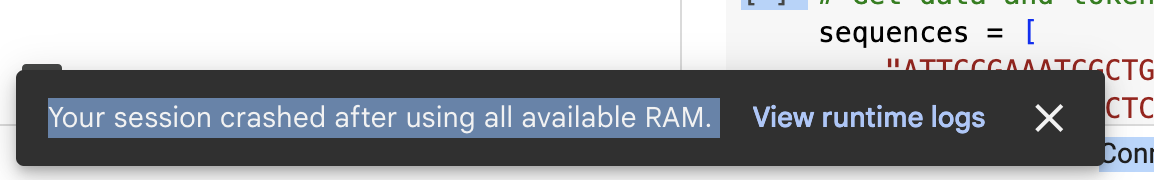

In [ ]:
import time
import numpy as np
import jax
import jax.numpy as jnp
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# 选取前 50 条样本
subset = df_vcf.iloc[:200].copy()

# Step 1: 提取序列
sequences_ref = subset["Context_Sequence"].tolist()
sequences_mut = subset["Mutant_Sequence"].tolist()

# Step 2: Tokenize
print("🔄 Tokenizing...")
start_time = time.time()

tokens_ids_ref = [b[1] for b in tokenizer.batch_tokenize(sequences_ref)]
tokens_ids_mut = [b[1] for b in tokenizer.batch_tokenize(sequences_mut)]

tokens_ref = jnp.asarray(tokens_ids_ref, dtype=jnp.int32)
tokens_mut = jnp.asarray(tokens_ids_mut, dtype=jnp.int32)

print(f"✅ Tokenization 完成，用时：{time.time() - start_time:.2f} 秒")
print("🧪 token_ref shape:", tokens_ref.shape)
print("🧪 token_mut shape:", tokens_mut.shape)

🔄 Tokenizing...
✅ Tokenization 完成，用时：1.65 秒
🧪 token_ref shape: (200, 512)
🧪 token_mut shape: (200, 512)


In [ ]:
import time

# Step 3: 前向推理，生成 embedding
print("🚀 Running forward inference...")

start_time = time.time()
random_key_ref = jax.random.PRNGKey(42)
random_key_mut = jax.random.PRNGKey(43)

outs_ref = forward_fn.apply(parameters, random_key_ref, tokens_ref)
outs_mut = forward_fn.apply(parameters, random_key_mut, tokens_mut)

embs_ref = jnp.mean(outs_ref["embeddings_12"], axis=1)
embs_mut = jnp.mean(outs_mut["embeddings_12"], axis=1)

embs_ref_np = np.array(embs_ref)
embs_mut_np = np.array(embs_mut)

print(f"✅ 推理完成，用时：{time.time() - start_time:.2f} 秒")

🚀 Running forward inference...


# rest code from the paper

## Define your input data and tokenize it
You can have a look at the tokens_str variable to see how your sequences have been split into tokens. The sequences will all be padded to the value you filled for max_positions.

In [ ]:
# Get data and tokenize it
sequences = [
    "ATTCCGAAATCGCTGACCGATCGTACGAAA",
    "ATTTCTCTCTCTCTCTGAGATCGATCGATCGATATCTCTCGAGCTAGC",
]
tokens_ids = [b[1] for b in tokenizer.batch_tokenize(sequences)]
tokens_str = [b[0] for b in tokenizer.batch_tokenize(sequences)]
tokens = jnp.asarray(tokens_ids, dtype=jnp.int32)

## Do the Inference
The first time you query this cell will be slower than usual inference because of the computation graph compilation.

In [ ]:
%%time
# Initialize random key
random_key = jax.random.PRNGKey(0)

# Infer
outs = forward_fn.apply(parameters, random_key, tokens)

CPU times: user 9.26 s, sys: 1.12 s, total: 10.4 s
Wall time: 7.11 s


In [ ]:
print(outs.keys())

dict_keys(['attention_map_layer_1_number_4', 'attention_map_layer_7_number_16', 'embeddings_12', 'logits'])


## Retrieve embeddings
And use them as you please! Enjoy!

In [ ]:
print(outs["embeddings_12"].shape)

(2, 32, 1280)


**Additional Tip**: Don't forget to remove the cls token and padded positions if you want for instance to compute mean embeddings!

In [ ]:
embeddings = outs["embeddings_12"][:, 1:, :]  # removing CLS token
padding_mask = jnp.expand_dims(tokens[:, 1:] != tokenizer.pad_token_id, axis=-1)
masked_embeddings = embeddings * padding_mask  # multiply by 0 pad tokens embeddings
sequences_lengths = jnp.sum(padding_mask, axis=1)
mean_embeddings = jnp.sum(masked_embeddings, axis=1) / sequences_lengths

In [ ]:
print(mean_embeddings.shape)

(2, 1280)


## Get attention maps
Here is an example on how to retrieve attention maps at a specific layer for a given head and how to plot them.

In [ ]:
print(outs["attention_map_layer_1_number_4"].shape)

(2, 32, 32)


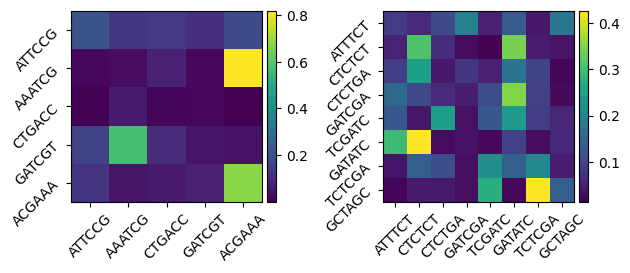

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# plot attention maps
fig, axes = plt.subplots(nrows=1, ncols=2)

seq_length0, seq_length1 = int(sequences_lengths[0][0]), int(sequences_lengths[1][0])

# plot for first seq in the batch
im0 = axes[0].imshow(
    outs["attention_map_layer_1_number_4"][
        0, 1 : (seq_length0 + 1), 1 : (seq_length0 + 1)
    ]
)
divider0 = make_axes_locatable(axes[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
tokens0 = tokens_str[0][1 : (seq_length0 + 1)]
axes[0].set_xticks(list(range(seq_length0)), tokens0, rotation=45)
axes[0].set_yticks(list(range(seq_length0)), tokens0, rotation=45)
fig.colorbar(im0, cax=cax0, orientation="vertical")

# plot for second seq in the batch
im1 = axes[1].imshow(
    outs["attention_map_layer_1_number_4"][
        1, 1 : (seq_length1 + 1), 1 : (seq_length1 + 1)
    ]
)
divider1 = make_axes_locatable(axes[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
tokens1 = tokens_str[1][1 : (seq_length1 + 1)]
axes[1].set_xticks(list(range(seq_length1)), tokens1, rotation=45)
axes[1].set_yticks(list(range(seq_length1)), tokens1, rotation=45)
fig.colorbar(im1, cax=cax1, orientation="vertical")

fig.tight_layout()

## Get probabilities
Finally, let's look at the model probabilities over the vocabulary at each position. These can be used notably to compute reconstruction accuracies and perplexities.

In [ ]:
logits = outs["logits"]
probabilities = []

# get probabilities separately for each seq as they have different lengths
for seq_id in range(logits.shape[0]):

    logits_seq = logits[seq_id]
    seq_length = int(sequences_lengths[seq_id][0])
    logits_seq = logits_seq[1 : (seq_length + 1)]  # remove CLS token and pads
    probas = jax.nn.softmax(
        logits_seq, axis=-1
    )  # use softmax to transform logits into probabilities

    print(probas.shape)
    probabilities.append(probas)

(5, 4105)
(8, 4105)


Let's look in particular at a given sequence and position and show the top-k probabilities and corresponding tokens.

In [ ]:
sequence_id = 0
position_id = 1

probs = probabilities[sequence_id][position_id]
sorted_positions = jnp.argsort(-probs)
sorted_probs = probs[sorted_positions]

top_k = 5
for k in range(top_k):
    predicted_token = tokenizer.id_to_token(int(sorted_positions[k]))
    prob = sorted_probs[k]
    print(f"token: {predicted_token}, probability: {prob * 100:.2f}%")

token: CTTCCT, probability: 26.59%
token: CTTTCT, probability: 9.63%
token: TTTCCT, probability: 4.15%
token: CTTCTC, probability: 3.31%
token: CTTTTC, probability: 2.59%
